# The Perceptron & Intro to ML

# What are Neural Nets?
#### Neural nets are learning models inspired by the way the brain processes information.
#### In the brain, neurons are the fundamental units that transmit signals.

## Neurons
### Each neuron receives inputs from other neurons, processes those signals, and transmits an output to other neurons.

<img src="https://o.quizlet.com/Xk2EDkEe.zn19l2ddiGYag_b.png" alt="Neuron Diagram" width="400"/>

### In artificial neural networks, the same process is simulated using mathematical functions.
<img src="pictures/network.jpg" alt="Neuron Diagram" width="300"/>

# The Perceptron

<img src="pictures/general_percepton.png" alt="Neuron Diagram" width="300"/>


## Perceptron — The Neuron of a Machine Learning Model

#### Each 'neuron' in a neural network takes multiple inputs, applies weights (like synaptic strengths), and produces an output.
#### Through training, the network adjusts its weights, much like how the brain strengthens or weakens connections based on experience.

---

## Mathematically, the output of a perceptron is modeled as:

### f(x₁·w₁ + x₂·w₂ + ... + xₙ·wₙ + b) = y

- `x₁, x₂, ..., xₙ` are the inputs  
- `w₁, w₂, ..., wₙ` are the weights  
- `b` is the bias (similar to a neuron's firing threshold)  
- `f` is the activation function (e.g., step function: fire or don’t fire)  
- `y` is the final output

---

### In this demo, we’ll train a single perceptron to function as an **AND gate**.
That is, given a sample consisting of a pair of binary values (0s or 1s), we want our perceptron to output:
- `1` (True) **only if both inputs are 1**
- `0` (False) otherwise

---


## 🔢 Truth Table: AND Gate

| Input A | Input B | Output |
|---------|---------|--------|
|   0     |    0    |   0    |
|   0     |    1    |   0    |
|   1     |    0    |   0    |
|   1     |    1    |   1    |

This means the perceptron should output 1 **only** when both inputs are 1.


# Building our Perceptron 
# Step 1: Imports and Data Setup

In [2]:
import numpy as np

# We are modeling an AND gate, so we define all combinations of two binary inputs and the correct outputs (labels) for each.

# Define training inputs
inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Labels for AND logic
labels = np.array([0, 0, 0, 1])


#  Step 2: Initialize the Model

In [3]:
 # Initialize weights and bias
weights = np.zeros(2)
bias = 0.0

# Learning rate controls how big each update is
learning_rate = 0.1

## Our perceptron
<img src="pictures/two_input_perceptron.png" alt="Neuron Diagram" width="450"/>

# Step 3: Try Predicting Before Training

In [4]:
# Try predicting a sample BEFORE training

sample = np.array([1, 1])

linear_output = np.dot(sample, weights) + bias

prediction = 1 if linear_output > 0 else 0

print(f"Prediction before training for input {sample}: {prediction}")


Prediction before training for input [1 1]: 0


## Explanation:
### Before training, the model guesses based only on [0, 0] weights and zero bias.
### This is important to show how the perceptron starts with no knowledge.

# Step 4: Do One Training Pass (Single Epoch)

## 🧠 How the Perceptron Trains (Step-by-Step)

1. **Pair inputs and labels**  
   We use `zip(inputs, labels)` to loop through each training example alongside its correct output.

2. **Compute the weighted sum (linear output)**  
   For a given input vector $\mathbf{x} = [x_1, x_2, \dots, x_n]$ and weights $\mathbf{w} = [w_1, w_2, \dots, w_n]$, compute the linear output as:

   $$
   \text{linear\_output} = \sum_{i=1}^{n} x_i w_i + b = \mathbf{x} \cdot \mathbf{w} + b
   $$

3. **Apply the activation function**  
We use a step function to decide the output:
- If `linear_output > 0`, output is `1` (the neuron fires)
- Else, output is `0` (no firing)

4. **Compare with the correct answer**  
Compute the error as:


-            error = actual_label - predicted_output



6. **Update the weights and bias if the model was wrong**  
The perceptron learning rule adjusts the weights and bias in the direction that would correct the error:

- `weights = weights + (learning_rate × error × input)`
- `bias = bias + (learning_rate × error)`

This update nudges the model closer to producing the correct output the next time it sees a similar input.

✅ The model learns **only when it's wrong**, and **only the weights associated with "active" inputs (non-zero)** get adjusted.


In [6]:
# Perform one epoch of training (one pass through data)
for x, y in zip(inputs, labels):
    linear_output = np.dot(x, weights) + bias
    prediction = 1 if linear_output > 0 else 0
    error = y - prediction

    print(f"Input: {x}, Prediction: {prediction}, Label: {y}, Error: {error}")

    # Update weights and bias
    weights += learning_rate * error * x
    bias += learning_rate * error

    print(f"Updated weights: {weights}, Updated bias: {bias}\n")


Input: [0 0], Prediction: 0, Label: 0, Error: 0
Updated weights: [0. 0.], Updated bias: 0.0

Input: [0 1], Prediction: 0, Label: 0, Error: 0
Updated weights: [0. 0.], Updated bias: 0.0

Input: [1 0], Prediction: 0, Label: 0, Error: 0
Updated weights: [0. 0.], Updated bias: 0.0

Input: [1 1], Prediction: 0, Label: 1, Error: 1
Updated weights: [0.1 0.1], Updated bias: 0.1



In [7]:
# Now we'll see what our weights look like
weights

array([0.1, 0.1])

# Now let's see how our perceptron perfomrs after a single training pass

In [8]:
print("Predictions after one training pass:")
for x in inputs:
    linear_output = np.dot(x, weights) + bias
    prediction = 1 if linear_output > 0 else 0
    print(f"{x} -> {prediction}")


Predictions after one training pass:
[0 0] -> 1
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1


## Explanation:
### After one pass, the model should already be doing better — at least for [1, 1].

### You can then repeat training for more epochs if needed, or show that a single pass can already lead to learning.

## One forward pass didnt fix it, but how about several training epochs? 
### Let's start a loop for a fixed number of epochs and see at the end if we've successfuly replicated an AND gate.

In [9]:
epochs = 50
# Training loop
for _ in range(epochs):
    for x, y in zip(inputs, labels):
        linear_output = np.dot(x, weights) + bias
        prediction = 1 if linear_output > 0 else 0
        error = y - prediction

        # Perceptron learning rule
        weights += learning_rate * error * x
        bias += learning_rate * error
print('Epochs complete.')

Epochs complete.


In [10]:
# Now we'll do a single forward pass just to see how our perceptron classifies the inputs initially
# Testing
for truth_condition in inputs:
    result = 1 if np.dot(truth_condition, weights) + bias > 0 else 0
    print(f"{x} -> {result}")


[1 1] -> 0
[1 1] -> 0
[1 1] -> 0
[1 1] -> 1


## 🧠 How the Perceptron Learns (Step-by-Step)

1. Pair inputs with their correct labels
   We iterate through each training input and its corresponding correct output using:
   
   for x, y_true in zip(inputs, labels):
   
2. **Compute the weighted sum (linear output)**  
   For an input vector $\mathbf{x} = [x_1, x_2, \dots, x_n]$ and a weight vector $\mathbf{w} = [w_1, w_2, \dots, w_n]$, compute:
   $$\text{linear\_output} = \mathbf{x} \cdot \mathbf{w} + b = \sum_{i=1}^{n} x_i w_i + b$$

3. **Apply the activation function (step function)**  
   The perceptron outputs 1 if the weighted sum is greater than 0, otherwise it outputs 0:
   $$\hat{y} = 
   \begin{cases} 
   1 & \text{if linear\_output} > 0 \\
   0 & \text{otherwise}
   \end{cases}$$

4. **Compare with the correct label**  
   Calculate the prediction error:
   $$\text{error} = y_{\text{true}} - \hat{y}$$

5. **Update the weights and bias (if wrong)**  
   If the prediction was incorrect, update the weights and bias to reduce the error:
   $$\mathbf{w} \leftarrow \mathbf{w} + \eta \cdot \text{error} \cdot \mathbf{x}$$
   $$b \leftarrow b + \eta \cdot \text{error}$$
   where $\eta$ is the learning rate (a small constant like 0.1).

✅ The perceptron only updates when it makes a mistake, and only the weights connected to active (non-zero) inputs are adjusted. Over time, these updates shift the decision boundary until the perceptron correctly classifies all training examples.

$\eta$ is the learning rate — a small constant (e.g., 0.1) that controls how big each update is.

- If **$\eta$ is too large**, each weight update is too aggressive. You might **jump over the ideal values**, like skipping over the bottom of a valley when you're trying to descend.
- If **$\eta$ is too small**, updates are so tiny that learning becomes very slow — or might get **stuck near a suboptimal point** and never improve.


Multiplying by error × xᵢ ensures we:

Only update weights for inputs that were active (i.e., non-zero)

Correct in the right direction: If the output was too low, we increase the weights; if too high, we decrease them.

The learning rate helps us make small, gradual improvements instead of overshooting the correct values.

✅ The perceptron only updates when it makes a mistake, and only the weights connected to active (non-zero) inputs are adjusted. Over time, these updates shift the decision boundary until the perceptron correctly classifies all training examples.

---

### 🔧 Why Do We Use a Learning Rate?

The **learning rate** ($\eta$) is a small constant (e.g., 0.1) that controls how big each weight update is during training.

- If **$\eta$ is too large**, updates can be too aggressive — the model might **overshoot the optimal weights**, like jumping over the bottom of a valley.
- If **$\eta$ is too small**, learning is extremely slow or might get **stuck near a suboptimal point**, unable to make meaningful progress.

The learning rate helps ensure the model improves **steadily and reliably** without becoming unstable.

---

### ✏️ Why Multiply by `error × xᵢ`?

Each weight update follows this rule:

$$
w_i \leftarrow w_i + \eta \cdot \text{error} \cdot x_i
$$

- **`error`** tells us **whether and how much the prediction was wrong**
- **`x_i`** ensures we only adjust weights for **inputs that were active** (i.e., non-zero)
- The sign of the update nudges the weight in the **right direction**:
  - If the output was **too low**, we increase the weight
  - If the output was **too high**, we decrease it

This formula ensures small, targeted corrections that push the perceptron closer to accurate predictions over time.


## 🎉 Summary: Did It Learn?

After training for number of epochs, our perceptron successfully learns the logic of an AND gate.

- It correctly classifies all input combinations
- It only outputs `1` when both inputs are `1`
- This shows how a simple model can learn from data using only vector math and a few rules!

This example also highlights the limits of a single-layer perceptron: it works for simple, linearly separable problems (like AND and OR), but **not** for more complex patterns like XOR — which require multi-layer networks (i.e., deeper models with hidden layers).


## 🎉 Summary: Did It Learn?

After training for several epochs, our perceptron successfully learns the logic of an AND gate.

- It correctly classifies all input combinations
- It only outputs `1` when both inputs are `1`
- This shows how a simple model can learn from data using only vector math and a few rules!

🧠 **Key takeaway:**  
The perceptron finds a **linear decision boundary** that separates input space based on whether the output should be `0` or `1`.

---

However, this example also highlights the **limits** of a single-layer perceptron:

- It works for linearly separable problems like **AND** and **OR**
- But it **cannot solve XOR**, where the output is not separable by a straight line

To solve problems like XOR, we need **multi-layer perceptrons (MLPs)** — deeper models that can learn nonlinear decision boundaries using hidden layers and more powerful activation functions.


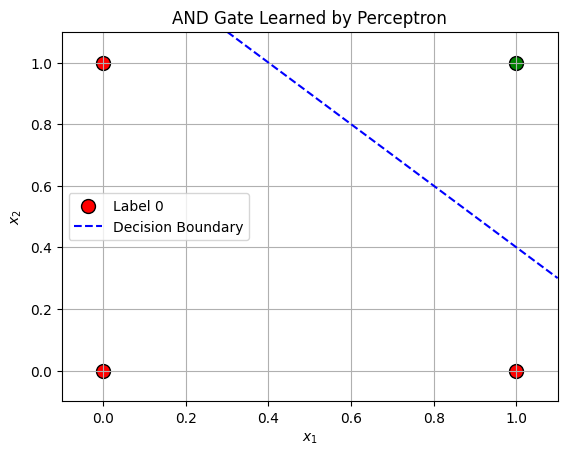

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Trained weights and bias (example — replace with your actual learned values)
weights = np.array([0.5, 0.5])
bias = -0.7  # Chosen so that only [1, 1] triggers output

# Inputs and labels for AND gate
inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
labels = np.array([0, 0, 0, 1])

# Plot data points
for i, label in enumerate(labels):
    color = 'red' if label == 0 else 'green'
    plt.scatter(inputs[i, 0], inputs[i, 1], c=color, s=100, edgecolors='k', label=f'Label {label}' if i == 0 else "")

# Plot decision boundary
x_vals = np.linspace(-0.1, 1.1, 100)
y_vals = -(weights[0] * x_vals + bias) / weights[1]
plt.plot(x_vals, y_vals, 'b--', label='Decision Boundary')

plt.title("AND Gate Learned by Perceptron")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.legend()
plt.show()


# Homework!

In [ ]:
## 📘 Problem Set: Train Your Brain (and Your Perceptron!)

1. **Modify the Truth Table**
   - Replace the `labels` array to model an **OR** gate instead of an AND gate.  
   - Run the training again. Does the perceptron learn it correctly?


In [66]:
# We are modeling an OR gate, so we define all combinations of two binary inputs and the correct outputs (labels) for each.

# Define training inputs
inputs = np.array([
    [0, 0],
    [0, 0],
    [0, 0],
    [0, 0]
])

# Labels for AND logic
labels = np.array([0, 0, 0, 0])

# Initialize weights and bias
weights = np.zeros(2)
bias = 0.0
# Learning rate controls how big each update is
learning_rate = 0.1

# Training loop
epochs = 50
for _ in range(epochs):
    for x, y in zip(inputs, labels):
        linear_output = np.dot(x, weights) + bias
        prediction = 1 if linear_output > 0 else 0
        error = y - prediction

        # Perceptron learning rule
        weights += learning_rate * error * x
        bias += learning_rate * error
print('Epochs complete.')

# Testing
for truth_condition in inputs:
    result = 1 if np.dot(truth_condition, weights) + bias > 0 else 0
    print(f"{x} -> {result}")


Epochs complete.
[0 0] -> 0
[0 0] -> 0
[0 0] -> 0
[0 0] -> 0


2. **Try a Bad Initialization**
   - Set the initial weights to `np.array([5.0, -3.0])` and `bias = 2.0`.  
   - What happens to the training? Can the perceptron still learn?


# Bonus! 
❓ **Challenge Question: Why can't a single-layer perceptron model the XOR function?**

The XOR gate outputs `1` only when the inputs are different:

| Input A | Input B | XOR Output |
|---------|---------|------------|
|   0     |    0    |     0      |
|   0     |    1    |     1      |
|   1     |    0    |     1      |
|   1     |    1    |     0      |

Try plotting these four input combinations on a 2D graph. Can you draw a single straight line that separates the `1`s from the `0`s?

Use your answer to explain why a single-layer perceptron, which creates only a linear boundary, is unable to learn XOR — and why deeper networks are necessary.
